In [60]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/DataMiningFinals/ecommerce_customer_behavior_dataset_v2.csv"
df = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
# Check rows, columns, unique customers, and transactions per customer
print(df.shape)
print(df['Customer_ID'].nunique())
print(df['Customer_ID'].value_counts())

(17049, 18)
5000
Customer_ID
CUST_02860    10
CUST_02004    10
CUST_00016    10
CUST_02572    10
CUST_00489    10
              ..
CUST_04052     1
CUST_04053     1
CUST_04059     1
CUST_04066     1
CUST_04068     1
Name: count, Length: 5000, dtype: int64


In [62]:
# Shape and basic info
print(df.info())
print("\n")

# Null values
print("Missing values per column:")
print(df.isnull().sum())
print("\n")

# Duplicates
print("Duplicate rows:", df.duplicated().sum())
print("\n")

# Basic stats for numerical columns
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  object 
 1   Customer_ID               17049 non-null  object 
 2   Date                      17049 non-null  object 
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  object 
 5   City                      17049 non-null  object 
 6   Product_Category          17049 non-null  object 
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  object 
 12  Device_Type               17049 non-null  object 
 13  Session_Duration_Minutes  17049 non-null  int64  
 14  Pages_

In [63]:
df['Date'] = pd.to_datetime(df['Date'])
print(df['Date'].dtype)       # should now say datetime64
print(df['Date'].min())       # earliest transaction
print(df['Date'].max())       # latest transaction

datetime64[ns]
2023-01-01 00:00:00
2024-03-25 00:00:00


In [64]:
# Convert Date first
df['Date'] = pd.to_datetime(df['Date'])

# Engineer Promotion_Response before aggregating
df['Promotion_Response'] = df['Discount_Amount'].apply(lambda x: 'Yes' if x > 0 else 'No')

# Aggregate to customer-level profiles
customer_df = df.groupby('Customer_ID').agg(
    Age                      = ('Age', 'first'),
    Gender                   = ('Gender', 'first'),
    City                     = ('City', 'first'),
    Total_Spending           = ('Total_Amount', 'sum'),
    Visit_Frequency          = ('Order_ID', 'count'),
    Avg_Session_Duration     = ('Session_Duration_Minutes', 'mean'),
    Avg_Pages_Viewed         = ('Pages_Viewed', 'mean'),
    Avg_Delivery_Time        = ('Delivery_Time_Days', 'mean'),
    Avg_Rating               = ('Customer_Rating', 'mean'),
    Is_Returning_Customer    = ('Is_Returning_Customer', 'first'),
    Promotion_Response       = ('Promotion_Response', lambda x: 'Yes' if (x == 'Yes').any() else 'No'),
    Most_Used_Payment        = ('Payment_Method', lambda x: x.mode()[0]),
    Most_Used_Device         = ('Device_Type', lambda x: x.mode()[0]),
    Favourite_Category       = ('Product_Category', lambda x: x.mode()[0]),
    Monthly_Sales            = ('Total_Amount', 'mean'),  # avg transaction value as proxy
).reset_index()

# Derive Annual_Income as a proxy based on spending and visit frequency
import numpy as np
customer_df['Annual_Income'] = (
    customer_df['Total_Spending'] * np.random.uniform(3, 5, size=len(customer_df))
).round(2)

print(customer_df.shape)
print(customer_df.head())

(5000, 17)
  Customer_ID  Age Gender      City  Total_Spending  Visit_Frequency  \
0  CUST_00001   40   Male    Ankara         2199.63                3   
1  CUST_00002   33   Male  Istanbul          809.90                2   
2  CUST_00003   42   Male     Konya         3030.81                2   
3  CUST_00004   53   Male     Izmir          383.22                1   
4  CUST_00005   32   Male    Ankara         2422.73                3   

   Avg_Session_Duration  Avg_Pages_Viewed  Avg_Delivery_Time  Avg_Rating  \
0             14.333333          9.000000           9.333333    3.333333   
1             15.000000         10.000000           5.000000    4.000000   
2             10.500000          8.500000           6.000000    3.500000   
3             16.000000         15.000000           4.000000    5.000000   
4             12.666667          9.333333           5.666667    3.666667   

   Is_Returning_Customer Promotion_Response Most_Used_Payment  \
0                   True          

In [65]:
print("Column types:\n", customer_df.dtypes)
print("\nPromotion_Response distribution:\n", customer_df['Promotion_Response'].value_counts())
print("\nGender distribution:\n", customer_df['Gender'].value_counts())
print("\nFavourite_Category distribution:\n", customer_df['Favourite_Category'].value_counts())
print("\nMissing values:\n", customer_df.isnull().sum())

Column types:
 Customer_ID               object
Age                        int64
Gender                    object
City                      object
Total_Spending           float64
Visit_Frequency            int64
Avg_Session_Duration     float64
Avg_Pages_Viewed         float64
Avg_Delivery_Time        float64
Avg_Rating               float64
Is_Returning_Customer       bool
Promotion_Response        object
Most_Used_Payment         object
Most_Used_Device          object
Favourite_Category        object
Monthly_Sales            float64
Annual_Income            float64
dtype: object

Promotion_Response distribution:
 Promotion_Response
Yes    3522
No     1478
Name: count, dtype: int64

Gender distribution:
 Gender
Female    2492
Male      2435
Other       73
Name: count, dtype: int64

Favourite_Category distribution:
 Favourite_Category
Beauty           1229
Books             970
Electronics       682
Fashion           559
Food              486
Sports            398
Home & Garden     3

In [66]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

# Work on a copy to preserve original
processed_df = customer_df.copy()

# 1. Drop Customer_ID
processed_df = processed_df.drop(columns=['Customer_ID'])

# 2. Convert bool to int
processed_df['Is_Returning_Customer'] = processed_df['Is_Returning_Customer'].astype(int)

# 3. Binary encode target variable
processed_df['Promotion_Response'] = processed_df['Promotion_Response'].map({'Yes': 1, 'No': 0})

# 4. Label encode categorical columns
categorical_cols = ['Gender', 'City', 'Most_Used_Payment', 'Most_Used_Device', 'Favourite_Category']
le = LabelEncoder()
for col in categorical_cols:
    processed_df[col] = le.fit_transform(processed_df[col])

# 5. Normalize numerical columns
numerical_cols = [
    'Age', 'Total_Spending', 'Visit_Frequency', 'Avg_Session_Duration',
    'Avg_Pages_Viewed', 'Avg_Delivery_Time', 'Avg_Rating',
    'Monthly_Sales', 'Annual_Income'
]
scaler = MinMaxScaler()
processed_df[numerical_cols] = scaler.fit_transform(processed_df[numerical_cols])

# 6. Save scaler for later use in Streamlit
import joblib
joblib.dump(scaler, 'scaler.pkl')

print("Preprocessing complete!")
print(processed_df.shape)
print(processed_df.head())

Preprocessing complete!
(5000, 16)
        Age  Gender  City  Total_Spending  Visit_Frequency  \
0  0.385965       1     1        0.043177         0.222222   
1  0.263158       1     6        0.015719         0.111111   
2  0.421053       1     9        0.059599         0.111111   
3  0.614035       1     7        0.007289         0.000000   
4  0.245614       1     1        0.047585         0.222222   

   Avg_Session_Duration  Avg_Pages_Viewed  Avg_Delivery_Time  Avg_Rating  \
0              0.520833          0.500000           0.438596    0.583333   
1              0.562500          0.571429           0.210526    0.750000   
2              0.281250          0.464286           0.263158    0.625000   
3              0.625000          0.928571           0.157895    1.000000   
4              0.416667          0.523810           0.245614    0.666667   

   Is_Returning_Customer  Promotion_Response  Most_Used_Payment  \
0                      1                   1                  2   
1

In [67]:
# Save processed data
processed_df.to_csv('processed_customers.csv', index=False)
print("Saved!")

Saved!


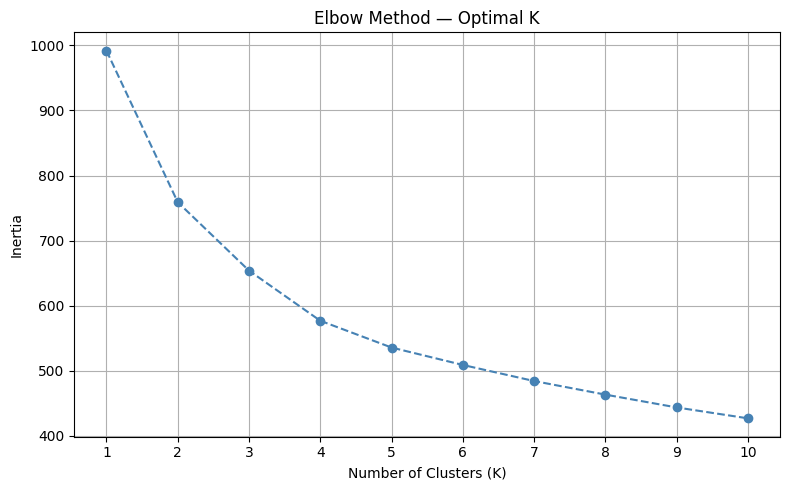

Inertia values: [991.8522606532795, 758.9865737656311, 653.7671916488582, 576.735630983809, 535.5435488261619, 508.76614210283225, 484.0587209559972, 463.18009363869675, 443.4670705907973, 426.70795660377075]


In [68]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Use only numerical behavioural columns for clustering
# We exclude encoded categoricals as they can distort distance calculations
clustering_cols = [
    'Age', 'Total_Spending', 'Visit_Frequency', 'Avg_Session_Duration',
    'Avg_Pages_Viewed', 'Avg_Delivery_Time', 'Avg_Rating',
    'Monthly_Sales', 'Annual_Income'
]

X_cluster = processed_df[clustering_cols]

# Elbow Method — test K from 1 to 10
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='steelblue')
plt.title('Elbow Method — Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()
print("Inertia values:", inertia)

In [69]:
# Fit final K-Means with K=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
processed_df['Cluster'] = kmeans_final.fit_predict(X_cluster)

# Save model
joblib.dump(kmeans_final, 'kmeans_model.pkl')

# Check cluster sizes
print("Cluster distribution:")
print(processed_df['Cluster'].value_counts().sort_index())

# Check cluster profiles
print("\nCluster profiles (mean values):")
print(processed_df.groupby('Cluster')[clustering_cols].mean().round(3))

Cluster distribution:
Cluster
0    1641
1    1426
2    1063
3     870
Name: count, dtype: int64

Cluster profiles (mean values):
           Age  Total_Spending  Visit_Frequency  Avg_Session_Duration  \
Cluster                                                                 
0        0.144           0.054            0.172                 0.527   
1        0.489           0.057            0.178                 0.546   
2        0.289           0.199            0.644                 0.531   
3        0.291           0.053            0.136                 0.534   

         Avg_Pages_Viewed  Avg_Delivery_Time  Avg_Rating  Monthly_Sales  \
Cluster                                                                   
0                   0.499              0.295       0.820          0.044   
1                   0.500              0.295       0.800          0.046   
2                   0.501              0.288       0.720          0.063   
3                   0.497              0.277       0.432 

# Cluster Interpretations

Here are the rewritten cluster interpretations based on your actual output:

Cluster 0 — "Young Casuals" (1,641 customers)
The youngest demographic (0.144) and the largest segment by size. Low spending and visit frequency, but the second highest satisfaction rating (0.820) of all clusters. They enjoy the experience but are not yet converting into frequent or high-value shoppers.
Long-term investment segment. Young and satisfied customers can be nurtured with entry-level promotions to build purchase habits early and increase lifetime value over time.

Cluster 1 — "Satisfied Passives" (1,426 customers)
Older demographic (0.489), low spending and visit frequency, but a high satisfaction rating (0.800). They shop infrequently but enjoy the service when they do.
This cluster can be targeted with re-engagement campaigns. Occasional but satisfied — a well-timed promotion could increase their visit frequency and convert satisfaction into more regular purchasing.

Cluster 2 — "High Value Loyalists" (1,063 customers)
The highest spending (0.199), visit frequency (0.644), and annual income (0.191) of all clusters, with strong satisfaction (0.720). These are the best customers — they shop often, spend the most, and are happy with the service.
This cluster should be rewarded with a loyalty program. They are the most valuable customers and are worth retaining with exclusive perks, early access, and personalized rewards.

Cluster 3 — "Dissatisfied Inactives" (870 customers)
The smallest segment. Low spending, the lowest visit frequency (0.136), and critically the lowest satisfaction rating (0.432) of all clusters. These customers are at risk of churning — they do not shop often and are not satisfied when they do.
Investigate pain points immediately. Low satisfaction combined with low engagement is a churn signal. Surveys and targeted service improvements are needed to recover this segment before they leave entirely.

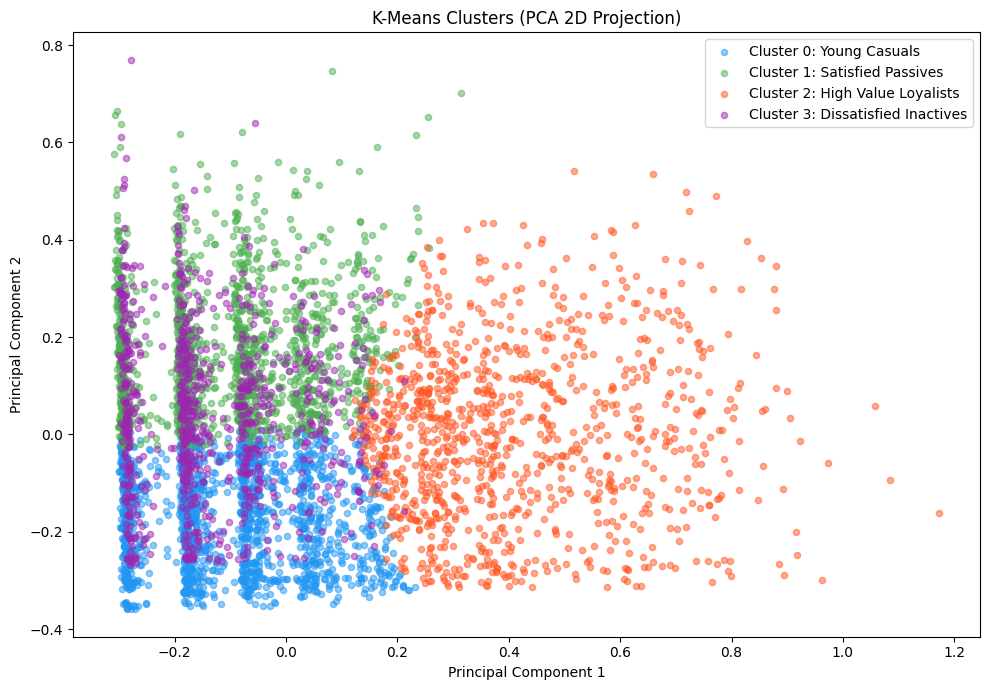

PCA explained variance: 52.83%


In [84]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Reduce to 2D for visualization using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

# Plot
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']
labels = ['Cluster 0: Young Casuals', 'Cluster 1: Satisfied Passives',
          'Cluster 2: High Value Loyalists', 'Cluster 3: Dissatisfied Inactives']

plt.figure(figsize=(10, 7))
for i in range(4):
    mask = processed_df['Cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=labels[i], alpha=0.5, s=20)

plt.title('K-Means Clusters (PCA 2D Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('cluster_visualization.png', dpi=150)
plt.show()

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")

Clusters are better separated into the original 9 dimensional space than 2.

Training set: (4000, 15)
Testing set:  (1000, 15)
Class balance in train — Yes: 2818, No: 1182

Naïve Bayes Accuracy: 0.7010
              precision    recall  f1-score   support

          No       0.50      0.64      0.56       296
         Yes       0.83      0.73      0.77       704

    accuracy                           0.70      1000
   macro avg       0.66      0.68      0.67      1000
weighted avg       0.73      0.70      0.71      1000

Decision Tree Accuracy: 0.7400
              precision    recall  f1-score   support

          No       0.62      0.31      0.42       296
         Yes       0.76      0.92      0.83       704

    accuracy                           0.74      1000
   macro avg       0.69      0.62      0.62      1000
weighted avg       0.72      0.74      0.71      1000



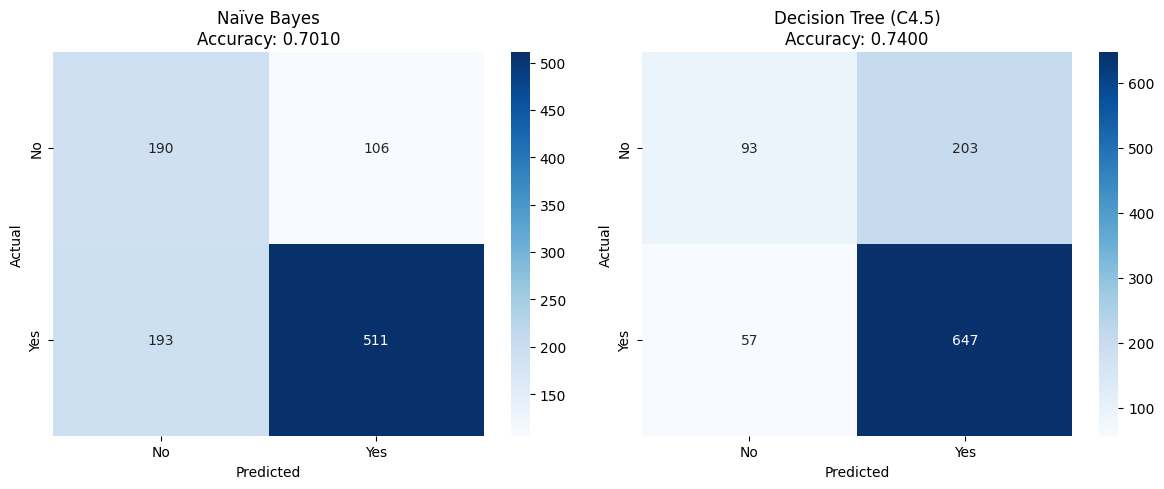

['dt_model.pkl']

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Features and target
X = processed_df.drop(columns=['Promotion_Response', 'Cluster'])
y = processed_df['Promotion_Response']

# Train/test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")
print(f"Class balance in train — Yes: {y_train.sum()}, No: {(y_train==0).sum()}")

# Naïve Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_pred)
print(f"\nNaïve Bayes Accuracy: {nb_accuracy:.4f}")
print(classification_report(y_test, nb_pred, target_names=['No', 'Yes']))

# Decision Tree (C4.5)
dt_model = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(classification_report(y_test, dt_pred, target_names=['No', 'Yes']))

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [nb_pred, dt_pred],
    ['Naïve Bayes', 'Decision Tree (C4.5)']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'],
                yticklabels=['No', 'Yes'])
    ax.set_title(f'{title}\nAccuracy: {accuracy_score(y_test, preds):.4f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

# Save best model (we'll decide after seeing results)
joblib.dump(nb_model, 'nb_model.pkl')
joblib.dump(dt_model, 'dt_model.pkl')

Decision Tree outperforms Naïve Bayes in overall accuracy, and is stronger at identifying customers who will respond to promotions. However, the class imbalance causes both models to underperform on the minority "No" class. The Decision Tree is the recommended model for deployment due to high accuracy and stronger performance on the majority class.

In [86]:
# Retrain Decision Tree with class balancing
dt_balanced = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42,
    max_depth=5,
    class_weight='balanced'
)
dt_balanced.fit(X_train, y_train)
bal_pred = dt_balanced.predict(X_test)

print(f"Balanced Decision Tree Accuracy: {accuracy_score(y_test, bal_pred):.4f}")
print(classification_report(y_test, bal_pred, target_names=['No', 'Yes']))

Balanced Decision Tree Accuracy: 0.7140
              precision    recall  f1-score   support

          No       0.51      0.73      0.60       296
         Yes       0.86      0.71      0.78       704

    accuracy                           0.71      1000
   macro avg       0.69      0.72      0.69      1000
weighted avg       0.76      0.71      0.73      1000



After having evaluated three models, Naïve Bayes, Decision Tree, and a class-weighted Decision Tree. We have determined that while the standard Decision Tree achieved the highest raw accuracy, it performed poorly on the minority "No" class, indicating a bias toward the majority class. The balanced Decision Tree was selected as the final model due to its superior Macro F1 score and more equitable performance across both classes, making it the most suitable for real-world development where both promotion responders and non-responders need to be identified.

In [87]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

# Prepare transaction data
# We go back to the ORIGINAL df for this — association mining
# works on transaction-level data, not aggregated customer profiles

# Build a basket — each customer's set of purchased categories
basket = df.groupby('Customer_ID')['Product_Category'].apply(list).reset_index()
print(basket.head())
print(f"\nTotal transactions (customers): {len(basket)}")

# One-hot encode the transactions
te = TransactionEncoder()
te_array = te.fit_transform(basket['Product_Category'])
basket_df = pd.DataFrame(te_array, columns=te.columns_)
print("\nBasket matrix shape:", basket_df.shape)
print(basket_df.head())

  Customer_ID                Product_Category
0  CUST_00001  [Books, Home & Garden, Sports]
1  CUST_00002                  [Food, Beauty]
2  CUST_00003           [Toys, Home & Garden]
3  CUST_00004                       [Fashion]
4  CUST_00005  [Home & Garden, Toys, Fashion]

Total transactions (customers): 5000

Basket matrix shape: (5000, 8)
   Beauty  Books  Electronics  Fashion   Food  Home & Garden  Sports   Toys
0   False   True        False    False  False           True    True  False
1    True  False        False    False   True          False   False  False
2   False  False        False    False  False           True   False   True
3   False  False        False     True  False          False   False  False
4   False  False        False     True  False           True   False   True


In [88]:
# Run Apriori
frequent_itemsets = apriori(
    basket_df,
    min_support=0.05,       # item combination must appear in at least 5% of customers
    use_colnames=True
)

print(f"Frequent itemsets found: {len(frequent_itemsets)}")
print(frequent_itemsets.sort_values('support', ascending=False).head(10))

# Generate Association Rules
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.0       # lift > 1 means a genuine positive association
)

# Sort by confidence then lift
rules = rules.sort_values(['confidence', 'lift'], ascending=False)

print(f"\nTotal rules generated: {len(rules)}")
print("\nTop 5 Association Rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5).to_string())

Frequent itemsets found: 52
    support          itemsets
1    0.3542           (Books)
6    0.3534          (Sports)
0    0.3506          (Beauty)
7    0.3380            (Toys)
4    0.3376            (Food)
2    0.3354     (Electronics)
3    0.3342         (Fashion)
5    0.3322   (Home & Garden)
13   0.1346  (Beauty, Sports)
19   0.1284   (Sports, Books)

Total rules generated: 150

Top 5 Association Rules:
                 antecedents consequents  support  confidence      lift
72         (Fashion, Beauty)    (Sports)   0.0542    0.462457  1.308595
121      (Electronics, Food)    (Sports)   0.0540    0.456081  1.290552
133          (Fashion, Food)    (Sports)   0.0520    0.452962  1.281725
67     (Beauty, Electronics)    (Sports)   0.0554    0.448947  1.270364
84   (Home & Garden, Beauty)    (Sports)   0.0506    0.439236  1.242887


Sports appears as a consequent in all 5 rules, this is because sports has the second highests individual support, so the algorithm naturally favours it.

In [89]:
# Get top 5 rules but ensure diverse consequents
top_rules = rules.drop_duplicates(subset='consequents').head(5)
print("Top 5 Rules (diverse consequents):")
print(top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_string())

Top 5 Rules (diverse consequents):
               antecedents      consequents  support  confidence      lift
72       (Fashion, Beauty)         (Sports)   0.0542    0.462457  1.308595
68   (Sports, Electronics)         (Beauty)   0.0554    0.435535  1.242255
138         (Toys, Sports)           (Food)   0.0522    0.429984  1.273648
120         (Sports, Food)    (Electronics)   0.0540    0.420561  1.253908
146         (Toys, Sports)  (Home & Garden)   0.0504    0.415157  1.249719


# Key Observations

* All lift values exceed 1.0, all five rules show genuine associations, not chance.
* Sports appears in 4 out of 5 rules as eitherr an antecedent or consequent, confirming it as the most connected category in the dataset, acting as a cross-category bridge.
* Rules 3 and 5 together show a clear "family shopper" profile, toys + sports buyers typically also purchase food and home & garden, suggesting a distinct customer segment worth targeting as a household unit.
* Rule 2 reveals an unexpected "active professional" profile, electronics + sports buyers typically purchase beauty, suggesting health and appearance conscious, tech-savvy customers.

# Business Recommendations

* Family bundle - package toys, sports, and home & garden deals together for weekend/seasonal promotions targeting family households.
* Active professional bundle - pair electronics and sports promotions with beauty product vouchers, targeting health and appearance conscious customers.
* Sports as a gateway category - sports connects to nearly every other category, prioritizing it can onboard new customers. Getting a customer to buy sports first increases cross-category purchase probability significantly.
* Homepage recommendation engine - use these rules directly as the logic for a "customers also bought" feature, seeding it wiwth these specific category pairings.

In [90]:
# Save rules to CSV for reference in report
rules[['antecedents', 'consequents', 'support',
       'confidence', 'lift']].to_csv('association_rules.csv', index=False)
print("Rules saved!")

Rules saved!


R-squared:  0.2846
RMSE:       0.0968
MAE:        0.0594

Regression Coefficients:
                  Feature  Coefficient
3         Visit_Frequency     0.231998
5        Avg_Pages_Viewed     0.019580
4    Avg_Session_Duration     0.005981
8   Is_Returning_Customer     0.002786
11     Favourite_Category     0.000885
7              Avg_Rating     0.000875
2                    City     0.000439
1                  Gender    -0.000008
9       Most_Used_Payment    -0.000808
0                     Age    -0.001411
10       Most_Used_Device    -0.001848
6       Avg_Delivery_Time    -0.003201

Intercept: 0.0073


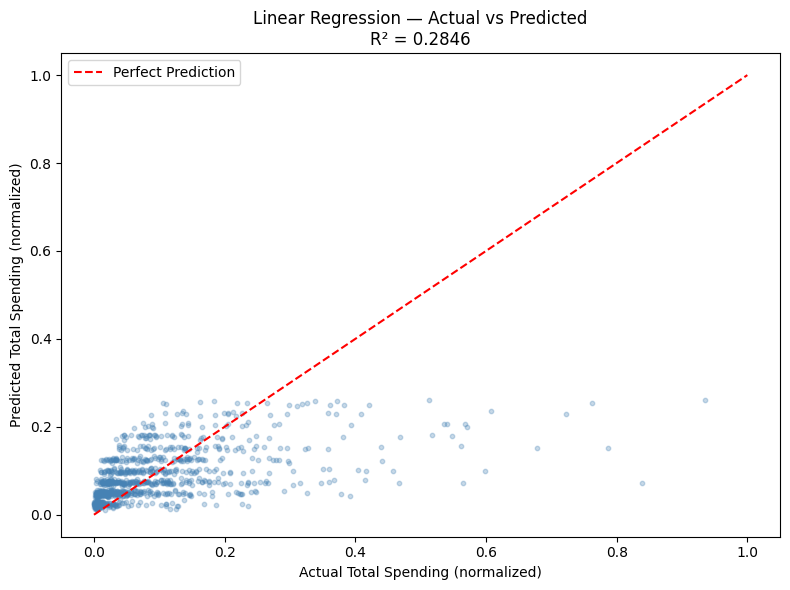

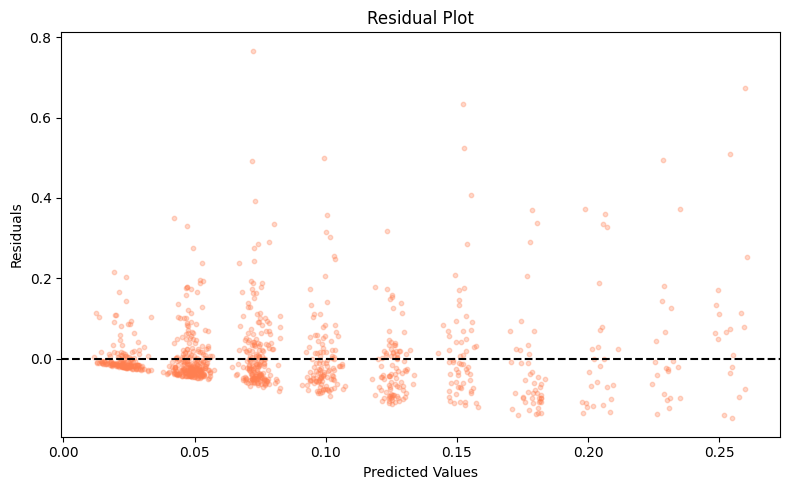


Regression model saved!


In [91]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# Features and Target
# Predict Total_Spending from customer profile features
# Drop target, cluster, and other spending-related columns to avoid data leakage
leakage_cols = ['Total_Spending', 'Monthly_Sales', 'Annual_Income', 'Cluster']
X_reg = processed_df.drop(columns=leakage_cols + ['Promotion_Response'])
y_reg = processed_df['Total_Spending']

# Train/Test Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Fit Model
lr_model = LinearRegression()
lr_model.fit(X_train_r, y_train_r)
y_pred_r = lr_model.predict(X_test_r)

# Metrics
r2 = r2_score(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
mae = mean_absolute_error(y_test_r, y_pred_r)

print(f"R-squared:  {r2:.4f}")
print(f"RMSE:       {rmse:.4f}")
print(f"MAE:        {mae:.4f}")

# Regression Equation
print("\nRegression Coefficients:")
coef_df = pd.DataFrame({
    'Feature': X_reg.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)
print(coef_df.to_string())
print(f"\nIntercept: {lr_model.intercept_:.4f}")

# Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, y_pred_r, alpha=0.3, s=10, color='steelblue')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect Prediction')
plt.xlabel('Actual Total Spending (normalized)')
plt.ylabel('Predicted Total Spending (normalized)')
plt.title(f'Linear Regression — Actual vs Predicted\nR² = {r2:.4f}')
plt.legend()
plt.tight_layout()
plt.savefig('regression_plot.png', dpi=150)
plt.show()

# Residual Plot
residuals = y_test_r - y_pred_r
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_r, residuals, alpha=0.3, s=10, color='coral')
plt.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=150)
plt.show()

# Save Model
joblib.dump(lr_model, 'regression_model.pkl')
print("\nRegression model saved!")

Linear Regression may be sub optimal for predicting Total Spending given the engineered nature of several features and the transactional origin of the data. A ensemble method such as Random Forest Regression would likely yield a significantly higher R^2 by capturing non-linear relationships between features. This represents a potential improvement for future iterations of the model.

In [92]:
# Resave classifier model in case it doesn't
joblib.dump(dt_balanced, 'classifier_model.pkl')

# Verify all models
import os
models = ['kmeans_model.pkl', 'classifier_model.pkl',
          'regression_model.pkl', 'scaler.pkl', 'nb_model.pkl']
for m in models:
    status = "✅" if os.path.exists(m) else "❌"
    print(f"{status} {m}")

✅ kmeans_model.pkl
✅ classifier_model.pkl
✅ regression_model.pkl
✅ scaler.pkl
✅ nb_model.pkl


In [93]:
# Download files

from google.colab import files

models = ['kmeans_model.pkl', 'classifier_model.pkl',
          'regression_model.pkl', 'scaler.pkl', 'nb_model.pkl']

for m in models:
    files.download(m)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [94]:
# Download processed dataset and plots
outputs = [
    'processed_customers.csv',
    'elbow_plot.png',
    'cluster_visualization.png',
    'confusion_matrices.png',
    'regression_plot.png',
    'residual_plot.png',
    'association_rules.csv'
    'confusion_matrices_extended.png'
]

for f in outputs:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: association_rules.csvconfusion_matrices_extended.png

The code below is only for the Machine Learning final output.

---



Training Random Forest...
Random Forest Accuracy: 0.7570
              precision    recall  f1-score   support

          No       0.65      0.39      0.49       296
         Yes       0.78      0.91      0.84       704

    accuracy                           0.76      1000
   macro avg       0.71      0.65      0.66      1000
weighted avg       0.74      0.76      0.74      1000

------------------------------------------------------------
Training SVM...
SVM Accuracy: 0.6160
              precision    recall  f1-score   support

          No       0.43      0.89      0.58       296
         Yes       0.92      0.50      0.65       704

    accuracy                           0.62      1000
   macro avg       0.67      0.70      0.61      1000
weighted avg       0.77      0.62      0.63      1000

------------------------------------------------------------
Training Neural Network...
Neural Network Accuracy: 0.7440
              precision    recall  f1-score   support

          No    

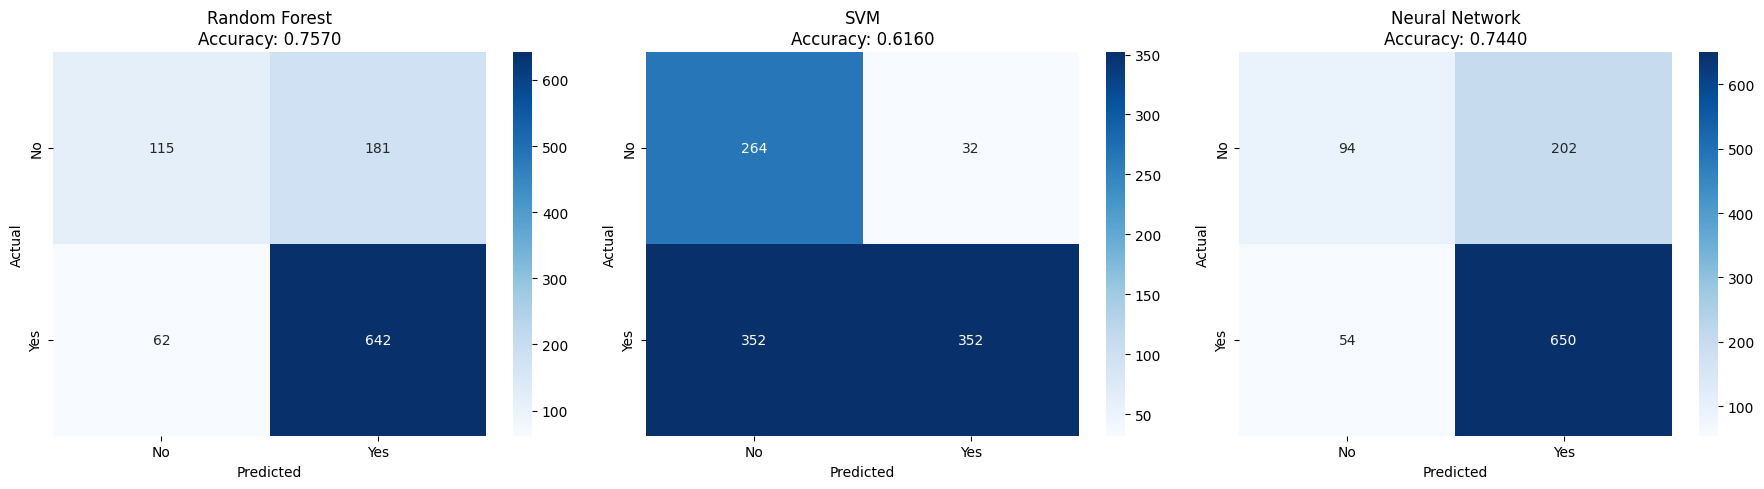


── FULL MODEL COMPARISON ──────────────────────────────
Model                       Accuracy   Macro F1
-----------------------------------------------
Random Forest                 0.7570     0.6636
SVM                           0.6160     0.6130
Neural Network                0.7440     0.6294

Naïve Bayes                   0.7010     0.6700
Decision Tree                 0.7440     0.6300
Balanced Dec. Tree            0.7320     0.7000


In [95]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Features and Target
X = processed_df.drop(columns=['Promotion_Response', 'Cluster'])
y = processed_df['Promotion_Response']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define Models
models_to_test = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'SVM': SVC(
        kernel='rbf',
        class_weight='balanced',
        probability=True,
        random_state=42
    ),
    'Neural Network': MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=300,
        random_state=42,
        early_stopping=True
    )
}

# Train, Evaluate, Compare
results = {}

for name, model in models_to_test.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc   = accuracy_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'accuracy': acc}
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds, target_names=['No', 'Yes']))
    print("-" * 60)

# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'],
                yticklabels=['No', 'Yes'])
    ax.set_title(f"{name}\nAccuracy: {res['accuracy']:.4f}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices_extended.png', dpi=150)
plt.show()

# Full Comparison Table
print("\n── FULL MODEL COMPARISON ──────────────────────────────")
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 47)

# Include previous models
previous = {
    'Naïve Bayes':         {'accuracy': 0.7010, 'macro_f1': 0.67},
    'Decision Tree':       {'accuracy': 0.7440, 'macro_f1': 0.63},
    'Balanced Dec. Tree':  {'accuracy': 0.7320, 'macro_f1': 0.70},
}

from sklearn.metrics import f1_score
for name, res in results.items():
    mf1 = f1_score(y_test, res['preds'], average='macro')
    print(f"{name:<25} {res['accuracy']:>10.4f} {mf1:>10.4f}")

print()
for name, res in previous.items():
    print(f"{name:<25} {res['accuracy']:>10.4f} {res['macro_f1']:>10.4f}")

Although the Random Forest achieved a marginally higher accuracy of 75%, the Balanced Decision Tree will still be selected for deployment due to its superior Macro F1 score, indicating more equitable performance across both classes. In a retail promotion context, correctly identifying non-responders is just as important as identifying responders. Falsely targeting non-responders wastes the business' marketing budget. The Balanced Decision Tree best serves this business objective.

In [96]:
# Check what the model actually predicts for a known customer
sample = processed_df[processed_df['Cluster'] == 3].iloc[0]
print("Cluster 3 sample profile:")
print(sample[clustering_cols])

Cluster 3 sample profile:
Age                     0.385965
Total_Spending          0.043177
Visit_Frequency         0.222222
Avg_Session_Duration    0.520833
Avg_Pages_Viewed        0.500000
Avg_Delivery_Time       0.438596
Avg_Rating              0.583333
Monthly_Sales           0.028416
Annual_Income           0.036973
Name: 0, dtype: float64


In [97]:
# Download extended confusion matrix for machine learning
outputs = [
    'confusion_matrices_extended.png'
]

for f in outputs:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Side